# XGBoostRegressor Training

## 1. Import Required Libraries

In [16]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Optimization
import optuna
import joblib
import math
import warnings

# Settings
sns.set(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("✅ Libraries imported.")

✅ Libraries imported.


## 2. Load and Explore Dataset

In [ ]:
# Load Dataset
try:
    df = pd.read_csv("data/typhoon_impact_cleaned.csv")
    
    # Standardize column names
    df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('/', '_')
    
    print(f"✅ Data Loaded. Shape: {df.shape}")

    # Define Features and Targets
    input_features = [
        'max_sustained_wind_kph',
        'typhoon_type',
        'max_24hr_rainfall_mm',
        'total_storm_rainfall_mm',
        'min_pressure_hpa',
        'duration_in_par_hours'
    ]

    target_columns = [
        'families', 'person', 'brgy', 'dead', 'injured_ill', 
        'missing', 'cost', 'partially', 'totally'
    ]
    
except FileNotFoundError:
    print("❌ Error: 'typhoon_impact_cleaned.csv' not found. Please upload the file.")

✅ Data Loaded. Shape: (1776, 30)


In [18]:
# Exploration of the dataset
print(f"Raw Data Loaded: {df.shape}")
print("-" * 50)

print("\n--- Dataset Information (Data Types) ---")
df.info()

print("\n--- Summary Statistics (Check for outliers in Raw Data) ---")
print(df.describe())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("-" * 50)
print("Preview of First 3 Rows:")
df.head(3)

Raw Data Loaded: (1776, 30)
--------------------------------------------------

--- Dataset Information (Data Types) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   typhoon_name             1776 non-null   object 
 1   year                     1776 non-null   int64  
 2   region                   1776 non-null   int64  
 3   province                 1776 non-null   object 
 4   city_municipality        1776 non-null   object 
 5   families                 1776 non-null   int64  
 6   person                   1776 non-null   int64  
 7   brgy                     1776 non-null   int64  
 8   dead                     1776 non-null   int64  
 9   injured_ill              1776 non-null   int64  
 10  missing                  1776 non-null   int64  
 11  totally                  1776 non-null   int64  
 12  partially  

,typhoon_name,year,region,province,city_municipality,families,person,brgy,dead,injured_ill,...,par_end,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_station_mapped,weather_records_found,weather_days_covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


## 4. Train-Test Split

In [19]:
# Create Feature Matrix X
X = df[input_features]
indices = df.index 

# 1. Train-Test Split (80/20)
X_train_raw, X_test_raw, idx_train, idx_test = train_test_split(
    X, indices, test_size=0.2, random_state=42
)

print("Data Split Complete.")
print(f"Raw Training Set Shape: {X_train_raw.shape}")
print(f"Raw Testing Set Shape:  {X_test_raw.shape}")

Data Split Complete.
Raw Training Set Shape: (1420, 6)
Raw Testing Set Shape:  (356, 6)


## 5. Feature Scaling

In [20]:
# Initialize the scaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Data Scaled Successfully.")
print(f"Scaled Train Shape: {X_train.shape}")
print(f"Scaled Test Shape:  {X_test.shape}")

ValueError: could not convert string to float: 'TY'

## 6. Basic Linear Regression Model Training

In [ ]:
baseline_metrics = []
baseline_models = {}

print(f"{'TARGET':<15} | {'BASELINE R2':<15} | {'BASELINE RMSE':<15}")
print("-" * 50)

for target in target_columns:
    # Get Target Data
    y_train = df.loc[idx_train, target]
    y_test_actual = df.loc[idx_test, target]

    # Initialize Default XGBoost
    model = XGBRegressor(random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    baseline_models[target] = model
    
    # Predict
    y_pred = np.maximum(model.predict(X_test), 0) # Enforce non-negative
    
    # Calculate Metrics
    r2 = r2_score(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    
    baseline_metrics.append({
        'Target': target,
        'Type': 'Baseline',
        'R2': r2,
        'RMSE': rmse
    })
    
    print(f"{target:<15} | {r2:.4f}          | {rmse:,.1f}")

print("\n✅ Baseline Training Complete.")

TARGET          | BASELINE R2     | BASELINE RMSE  
--------------------------------------------------
families        | -0.4748          | 1,414.4
person          | -1.2790          | 4,496.6
brgy            | 0.2421          | 4.7
dead            | 1.0000          | 0.0
injured_ill     | 0.0000          | 1.0
missing         | 1.0000          | 0.0
cost            | 0.3659          | 621,499.6
partially       | -0.5917          | 79.0
totally         | -13.9533          | 11.7

✅ Baseline Training Complete.


## 7. Hyperparameter Tuning with Optuna

In [ ]:
best_params_dict = {}

print("Starting Optuna Tuning...")
print(f"{'TARGET':<15} | {'BEST RMSE (CV)':<25}")
print("-" * 50)

for target in target_columns:
    y_train = df.loc[idx_train, target]
    
    def objective(trial):
        # Define search space for XGBoost
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
            'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
            'random_state': 42,
            'verbosity': 0,
            'n_jobs': -1
        }
        
        model = XGBRegressor(**param)
        
        # 3-Fold Cross Validation
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring='neg_mean_squared_error')
        rmse = np.sqrt(-scores.mean())
        return rmse

    # Minimize RMSE
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20)
    
    best_params_dict[target] = study.best_params
    print(f"{target:<15} | {study.best_value:,.4f}")

print("\n✅ Hyperparameter Tuning Complete.")

Starting Optuna Tuning...
TARGET          | BEST RMSE (CV)           
--------------------------------------------------
families        | 1,385.9403
person          | 6,128.2164
brgy            | 16.3583
dead            | -0.0000
injured_ill     | 0.5563
missing         | -0.0000
cost            | 786,421.4891
partially       | 64.0264
totally         | 8.1892

✅ Hyperparameter Tuning Complete.


In [ ]:
tuned_metrics = []
final_models = {}

# Check for metadata columns
metadata_cols = ['typhoon_name', 'province'] 
existing_metadata = [col for col in metadata_cols if col in df.columns]

# Initialize results dataframe
final_results_df = df.loc[idx_test, existing_metadata].copy().reset_index(drop=True)

print(f"{'TARGET':<15} | {'TUNED R2':<15} | {'IMPROVEMENT (R2)':<20}")
print("-" * 60)

for target in target_columns:
    # 1. Retrieve best params
    best_params = best_params_dict.get(target, {})
    
    # 2. Train Final Model
    model = XGBRegressor(**best_params, random_state=42, verbosity=0)
    y_train = df.loc[idx_train, target]
    model.fit(X_train, y_train)
    final_models[target] = model
    
    # 3. Predict
    y_test_actual = df.loc[idx_test, target]
    y_pred = np.maximum(model.predict(X_test), 0)
    
    # 4. Store Results
    final_results_df[f'{target}_Actual'] = y_test_actual.values
    final_results_df[f'{target}_Predicted'] = y_pred
    
    # 5. Metrics
    r2 = r2_score(y_test_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
    
    tuned_metrics.append({
        'Target': target,
        'Type': 'Tuned',
        'R2': r2,
        'RMSE': rmse
    })
    
    # 6. Compare
    try:
        baseline_r2 = next(item['R2'] for item in baseline_metrics if item['Target'] == target)
        improvement = r2 - baseline_r2
        imp_str = f"{improvement:+.4f}"
    except:
        imp_str = "N/A"
    
    print(f"{target:<15} | {r2:.4f}          | {imp_str}")

print("\n✅ Final Models Trained and Evaluated.")

TARGET          | TUNED R2        | IMPROVEMENT (R2)    
------------------------------------------------------------
families        | -0.1061          | +0.3687
person          | -0.5246          | +0.7544
brgy            | -0.2829          | -0.5250
dead            | 1.0000          | +0.0000
injured_ill     | 0.0000          | +0.0000
missing         | 1.0000          | +0.0000
cost            | 0.1774          | -0.1886
partially       | -0.2440          | +0.3477
totally         | -3.8965          | +10.0568

✅ Final Models Trained and Evaluated.


## 8. Model Evaluation and Validation

In [ ]:
performance_data = []

print(f"{'TARGET':<15} | {'R2 SCORE':<10} | {'MAE':<15} | {'RMSE':<15}")
print("-" * 75)

for target in target_columns:
    y_true = final_results_df[f'{target}_Actual']
    y_pred = final_results_df[f'{target}_Predicted']
    
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    performance_data.append({'Target': target, 'R2': r2, 'MAE': mae, 'RMSE': rmse})
    
    print(f"{target:<15} | {r2:.4f}     | {mae:,.2f}        | {rmse:,.2f}")

print("-" * 75)

TARGET          | R2 SCORE   | MAE             | RMSE           
---------------------------------------------------------------------------
families        | -0.1061     | 964.13        | 1,224.94
person          | -0.5246     | 3,121.04        | 3,677.82
brgy            | -0.2829     | 5.81        | 6.11
dead            | 1.0000     | 0.00        | 0.00
injured_ill     | 0.0000     | 0.15        | 0.15
missing         | 1.0000     | 0.00        | 0.00
cost            | 0.1774     | 482,427.42        | 707,909.98
partially       | -0.2440     | 37.33        | 69.89
totally         | -3.8965     | 4.03        | 6.70
---------------------------------------------------------------------------


## 10. Model Output and Summary

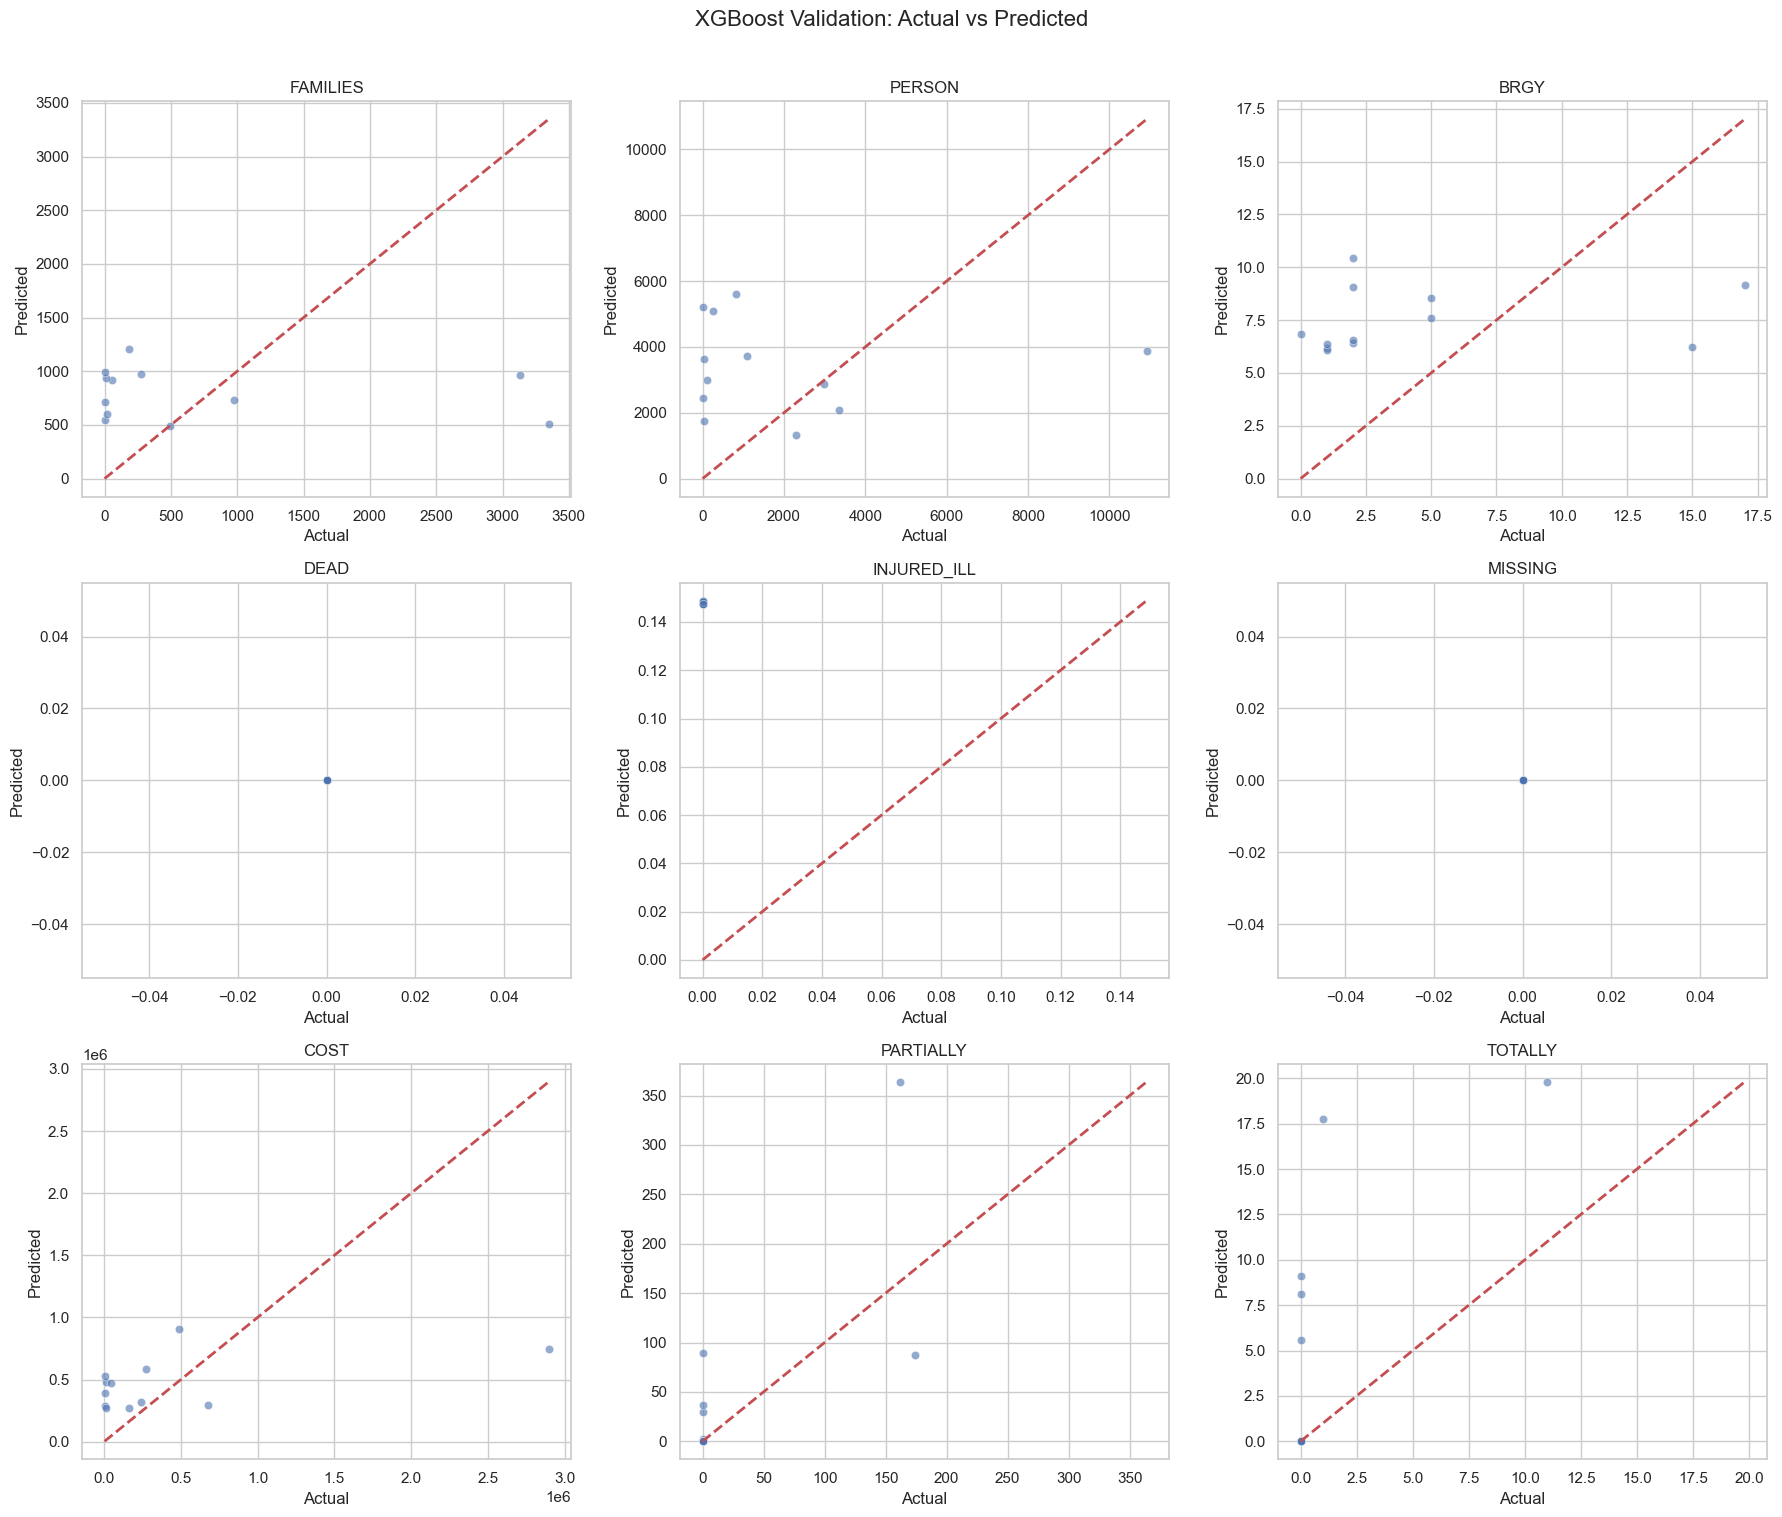

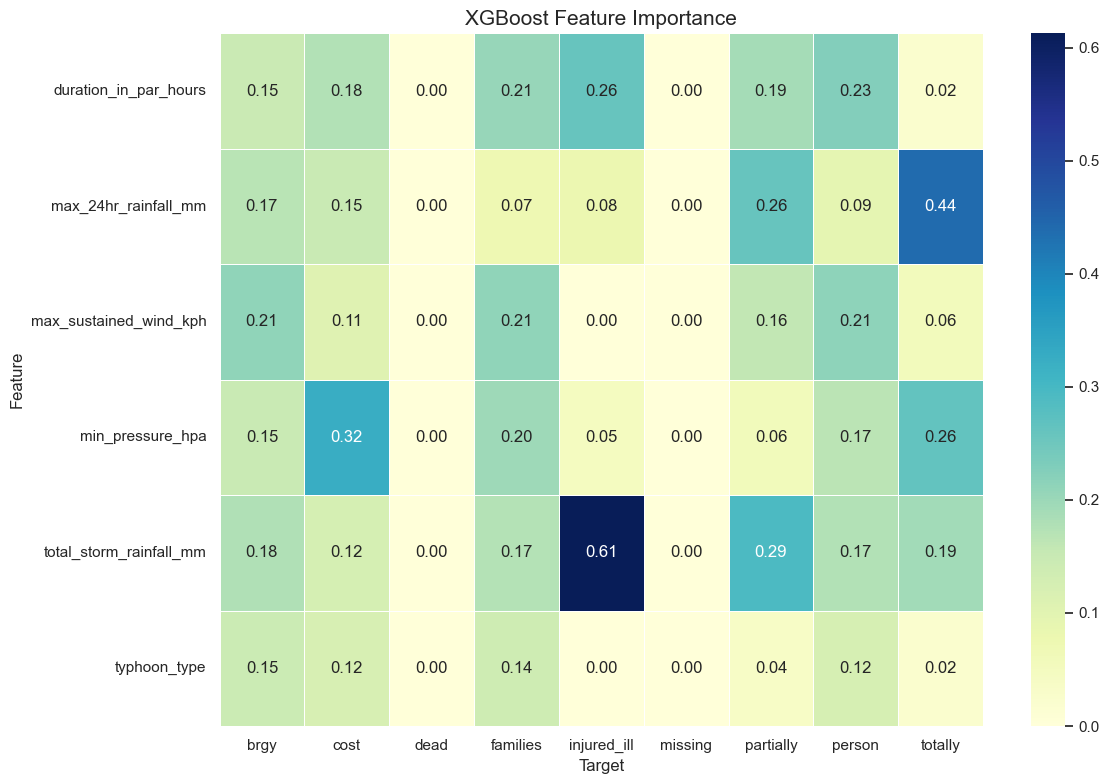

In [ ]:
# --- PART 1: Actual vs Predicted Scatter ---
cols = 3
rows = math.ceil(len(target_columns) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, target in enumerate(target_columns):
    ax = axes[i]
    y_true = final_results_df[f'{target}_Actual']
    y_pred = final_results_df[f'{target}_Predicted']
    
    sns.scatterplot(x=y_true, y=y_pred, ax=ax, alpha=0.6)
    
    # Perfect Fit Line
    max_val = max(y_true.max(), y_pred.max())
    min_val = min(y_true.min(), y_pred.min())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    ax.set_title(f'{target.upper()}', fontsize=12)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('XGBoost Validation: Actual vs Predicted', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# --- PART 2: Feature Importance (XGBoost) ---
feat_imp_data = []
for target in target_columns:
    model = final_models[target]
    # XGBoost uses .feature_importances_
    for feature, importance in zip(input_features, model.feature_importances_):
        feat_imp_data.append({'Target': target, 'Feature': feature, 'Importance': importance})

feat_df = pd.DataFrame(feat_imp_data)

plt.figure(figsize=(12, 8))
heatmap_data = feat_df.pivot(index='Feature', columns='Target', values='Importance')
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5)
plt.title('XGBoost Feature Importance', fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
# results_filename = 'final_predictions_xgb.csv'
# final_results_df.to_csv(results_filename, index=False)
# print(f"✅ Prediction results saved to: {results_filename}")

# # 2. Save Model Pipeline
# pipeline_artifacts = {
#     'models': final_models,
#     'scaler': scaler,
#     'input_features': input_features,
#     'target_columns': target_columns,
#     'best_params': best_params_dict
# }

# model_filename = 'xgb_prediction_pipeline.joblib'
# joblib.dump(pipeline_artifacts, model_filename)

# print(f"✅ XGBoost pipeline saved to: {model_filename}")

✅ Prediction results saved to: final_predictions_xgb.csv


In [ ]:
# def predictsample(x, y, z):
#     # Load the saved pipeline
#     model_filename = 'xgb_prediction_pipeline.joblib'
#     pipeline = joblib.load(model_filename)
    
#     models = pipeline['models']
#     scaler = pipeline['scaler']
#     input_features = pipeline['input_features']
    
#     # Create DataFrame for input
#     input_df = pd.DataFrame([[x, y, z]], columns=input_features)
    
#     # Scale input
#     input_scaled = scaler.transform(input_df)
    
#     # Make predictions for each target
#     predictions = {}
#     for target, model in models.items():
#         pred = model.predict(input_scaled)
#         predictions[target] = max(pred[0], 0)  # Enforce non-negative
    
#     return predictions